# 06 — Fare Regression
## Urban Mobility Intelligence Platform | Chicago TNC 2024

### Research Context
This notebook implements **Section IV-B: Fare Estimation** of the paper.

### Problem Statement
Predict the total fare for a trip given information available
at the time of booking — origin zone, destination zone, estimated
distance, temporal context, and demand conditions.

**Target:** log(trip_total) — log transformed for normality
**Evaluation:** R², RMSE, MAE in original dollar units
**Novel element:** Quantile regression — predict 10th, 50th, 90th
percentile fares, giving a prediction interval rather than a point estimate

### Modeling approach
1. Baseline — Ridge Regression
2. XGBoost — primary point estimate model
3. LightGBM Quantile Regression — P10, P50, P90 intervals
4. Residual spatial analysis — are errors spatially correlated?
5. Model comparison and selection

### Target metrics
- R²: 0.90+
- RMSE: under $4.00
- MAE: under $2.50

## Setup — Imports and Configuration

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

# paths
PARQUET_DIR = r"E:\Projects\ML\Transport taxi chicago\data\parquet"
PLOTS_DIR   = r"E:\Projects\ML\Transport taxi chicago\data\plots"
MODELS_DIR  = r"E:\Projects\ML\Transport taxi chicago\models"
REG_PATH    = os.path.join(PARQUET_DIR, "df_regression.parquet")

# plot styling
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#30363d'

print("Imports complete.")

Imports complete.


## 1. Load Data & Define Features
Load the regression parquet file and define feature columns.
Note: fare column excluded — near-perfect correlation with trip_total (r=0.96)
would constitute target leakage.
trip_total retained for inverse transform evaluation in original dollar units.

In [3]:
# load regression dataset
print("Loading regression dataset...")
df = pd.read_parquet(REG_PATH)
print(f"Shape: {df.shape}")
print(f"Avg fare: ${df['trip_total'].mean():.2f}")

# leakage prone features to exclude from regression
# same as classification plus any post-trip financials
leakage_features = [
    'trip_seconds',
    'log_trip_seconds',
    'trip_duration_bucket',
    'avg_speed_mph',
    'shared_trip_match',  # post-booking
    'is_surge',           # not available at booking — target of task 1
    'zone_surge_rate_24h' # derived from surge labels
]

# targets
TARGET     = 'log_trip_total'
TARGET_RAW = 'trip_total'

# feature columns
exclude = leakage_features + [TARGET, TARGET_RAW]
FEATURE_COLS = [c for c in df.columns if c not in exclude]

print(f"\nFeatures excluded (leakage): {len(leakage_features)}")
print(f"Features used              : {len(FEATURE_COLS)}")
print(f"\nFeature list:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2}. {col}")

Loading regression dataset...
Shape: (18229241, 49)
Avg fare: $23.20

Features excluded (leakage): 7
Features used              : 41

Feature list:
   1. trip_miles
   2. pickup_community_area
   3. dropoff_community_area
   4. shared_trip_authorized
   5. trips_pooled
   6. is_out_of_city
   7. hour
   8. dow
   9. month
  10. day_of_year
  11. hour_sin
  12. hour_cos
  13. dow_sin
  14. dow_cos
  15. month_sin
  16. month_cos
  17. is_weekend
  18. is_morning_peak
  19. is_evening_peak
  20. is_late_night
  21. is_holiday
  22. is_airport
  23. pickup_zone_freq
  24. dropoff_zone_freq
  25. pickup_zone_freq_norm
  26. dropoff_zone_freq_norm
  27. is_same_zone
  28. is_downtown_pickup
  29. is_downtown_dropoff
  30. log_trip_miles
  31. trip_distance_bucket
  32. is_pooled
  33. zone_hour_count
  34. lag_1h
  35. lag_24h
  36. lag_168h
  37. roll_3h
  38. roll_24h
  39. demand_vs_lag_ratio
  40. trip_count_vs_zone_avg
  41. is_rush_hour_downtown


## 2. Train/Test Split
Stratified split on trip_distance_bucket to ensure all distance
categories are represented proportionally in train and test sets.
Distance bucket stratification is more appropriate than random
stratification for fare regression — ensures the model is evaluated
on the full range of trip distances.

In [4]:
# train/test split — stratified on distance bucket
X = df[FEATURE_COLS]
y = df[TARGET]
y_raw = df[TARGET_RAW]

X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=df['trip_distance_bucket']
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nTrain avg fare: ${np.expm1(y_train).mean():.2f}")
print(f"Test avg fare : ${np.expm1(y_test).mean():.2f}")
print(f"\nDistance bucket distribution (test):")
print(X_test['trip_distance_bucket'].value_counts().sort_index().to_string())

# free memory
del df

Train size : 14,583,392
Test size  : 3,645,849

Train avg fare: $23.20
Test avg fare : $23.19

Distance bucket distribution (test):
trip_distance_bucket
1     917461
2    1106285
3     738196
4     663364
5     220543


## 3. Baseline — Ridge Regression
Ridge regression establishes a linear benchmark.
StandardScaler applied — required for regularized linear models.
Trained on 500K stratified sample — sufficient for linear baseline.
Results reported in original dollar units via inverse log transform.

In [4]:
# ridge regression baseline
# 500K stratified sample — sufficient for linear benchmark

print("Sampling 500K rows for Ridge baseline...")
X_train_sample, _, y_train_sample, _, y_raw_train_sample, _ = train_test_split(
    X_train, y_train, y_raw_train,
    train_size=500000,
    random_state=42,
    stratify=X_train['trip_distance_bucket']
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_test_scaled  = scaler.transform(X_test)

print("Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_sample)

# evaluate
ridge_preds_log = ridge.predict(X_test_scaled)
ridge_preds     = np.expm1(ridge_preds_log)
ridge_preds     = np.clip(ridge_preds, 0, 500)

ridge_r2   = r2_score(y_test, ridge_preds_log)
ridge_rmse = np.sqrt(mean_squared_error(y_raw_test, ridge_preds))
ridge_mae  = mean_absolute_error(y_raw_test, ridge_preds)

print(f"\nRidge Regression Results:")
print(f"  R²   : {ridge_r2:.4f}")
print(f"  RMSE : ${ridge_rmse:.2f}")
print(f"  MAE  : ${ridge_mae:.2f}")
print(f"  Avg predicted fare : ${ridge_preds.mean():.2f}")
print(f"  Avg actual fare    : ${y_raw_test.mean():.2f}")

Sampling 500K rows for Ridge baseline...
Training Ridge Regression...

Ridge Regression Results:
  R²   : 0.7589
  RMSE : $9.11
  MAE  : $5.43
  Avg predicted fare : $22.15
  Avg actual fare    : $23.19


## 4. Additional Feature Engineering for Regression
Features informed by fare prediction literature.
All features use only information available at booking time.

New features:
- zone_avg_fare: historical avg fare per pickup zone — strong zone-level pricing signal
- od_pair_freq: origin-destination pair frequency — common routes have predictable fares
- trip_miles_squared: captures non-linear distance-fare relationship
- miles_x_peak: interaction — long peak-hour trips command premium pricing
- miles_x_airport: airport trips have different per-mile rate structure

In [5]:
# additional feature engineering for regression

# zone average fare — historical pricing signal per pickup zone
zone_avg_fare = (
    X_train.join(y_raw_train)
    .groupby('pickup_community_area')['trip_total']
    .mean()
    .reset_index()
    .rename(columns={'trip_total': 'zone_avg_fare'})
)

# merge into train and test
X_train = X_train.merge(zone_avg_fare, on='pickup_community_area', how='left')
X_test  = X_test.merge(zone_avg_fare, on='pickup_community_area', how='left')

# od pair frequency — how common is this origin-destination combination
od_freq = (
    X_train.groupby(['pickup_community_area', 'dropoff_community_area'])
    .size()
    .reset_index(name='od_pair_freq')
)

X_train = X_train.merge(od_freq, on=['pickup_community_area', 'dropoff_community_area'], how='left')
X_test  = X_test.merge(od_freq, on=['pickup_community_area', 'dropoff_community_area'], how='left')

# fill nulls in test — unseen OD pairs
X_test['od_pair_freq'] = X_test['od_pair_freq'].fillna(1)

# normalize od pair frequency
X_train['od_pair_freq_norm'] = X_train['od_pair_freq'] / X_train['od_pair_freq'].max()
X_test['od_pair_freq_norm']  = X_test['od_pair_freq']  / X_train['od_pair_freq'].max()

# non-linear distance features
X_train['trip_miles_squared'] = X_train['trip_miles'] ** 2
X_test['trip_miles_squared']  = X_test['trip_miles'] ** 2

# interaction features
X_train['miles_x_peak']    = X_train['trip_miles'] * (
    X_train['is_morning_peak'] | X_train['is_evening_peak']).astype(int)
X_test['miles_x_peak']     = X_test['trip_miles'] * (
    X_test['is_morning_peak'] | X_test['is_evening_peak']).astype(int)

X_train['miles_x_airport'] = X_train['trip_miles'] * X_train['is_airport']
X_test['miles_x_airport']  = X_test['trip_miles']  * X_test['is_airport']

# update feature columns
FEATURE_COLS = [c for c in X_train.columns]

print(f"New features added: 5")
print(f"Total features    : {len(FEATURE_COLS)}")
print(f"\nNew feature stats (train):")
print(X_train[['zone_avg_fare', 'od_pair_freq', 
               'trip_miles_squared', 'miles_x_peak', 
               'miles_x_airport']].describe().round(2).to_string())

New features added: 5
Total features    : 47

New feature stats (train):
       zone_avg_fare  od_pair_freq  trip_miles_squared  miles_x_peak  miles_x_airport
count    14583392.00   14583392.00         14583392.00   14583392.00      14583392.00
mean           23.20      80310.85              112.17          2.53             1.08
std             8.07     113045.35              350.65          5.67             4.89
min            15.19          1.00                0.00          0.00             0.00
25%            18.58       5733.00                3.96          0.00             0.00
50%            20.36      26366.00               18.06          0.00             0.00
75%            24.03     111570.00               94.09          2.42             0.00
max            50.04     454709.00            22495.86        149.99           149.99


## 5. XGBoost — Primary Regression Model
XGBoost trained on full 14.58M training set.
Log-transformed target reduces skew and improves gradient boosting performance.
Early stopping prevents overfitting.
Results reported in original dollar units via inverse log transform (expm1).

In [6]:
# xgboost — primary regression model
# full 14.58M training set

print("Training XGBoost on full 14.58M training set...")
print("This will take 15-20 minutes...\n")

# validation split for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=X_train['trip_distance_bucket']
)

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# evaluate
xgb_preds_log = xgb_model.predict(X_test)
xgb_preds     = np.expm1(xgb_preds_log)
xgb_preds     = np.clip(xgb_preds, 0, 500)

xgb_r2   = r2_score(y_test, xgb_preds_log)
xgb_rmse = np.sqrt(mean_squared_error(y_raw_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_raw_test, xgb_preds)

print(f"\nXGBoost Results:")
print(f"  R²             : {xgb_r2:.4f}")
print(f"  RMSE           : ${xgb_rmse:.2f}")
print(f"  MAE            : ${xgb_mae:.2f}")
print(f"  Best iteration : {xgb_model.best_iteration}")
print(f"  Avg predicted  : ${xgb_preds.mean():.2f}")
print(f"  Avg actual     : ${y_raw_test.mean():.2f}")

Training XGBoost on full 14.58M training set...
This will take 15-20 minutes...

[0]	validation_0-rmse:0.56659
[100]	validation_0-rmse:0.25923
[200]	validation_0-rmse:0.25217
[300]	validation_0-rmse:0.24909
[400]	validation_0-rmse:0.24738
[500]	validation_0-rmse:0.24607
[600]	validation_0-rmse:0.24521
[700]	validation_0-rmse:0.24449
[800]	validation_0-rmse:0.24387
[900]	validation_0-rmse:0.24339
[1000]	validation_0-rmse:0.24297
[1100]	validation_0-rmse:0.24262
[1200]	validation_0-rmse:0.24230
[1300]	validation_0-rmse:0.24202
[1400]	validation_0-rmse:0.24178
[1500]	validation_0-rmse:0.24154
[1600]	validation_0-rmse:0.24135
[1700]	validation_0-rmse:0.24115
[1800]	validation_0-rmse:0.24099
[1900]	validation_0-rmse:0.24085
[1999]	validation_0-rmse:0.24072

XGBoost Results:
  R²             : 0.8327
  RMSE           : $7.66
  MAE            : $4.41
  Best iteration : 1999
  Avg predicted  : $22.47
  Avg actual     : $23.19


In [7]:
import joblib
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(xgb_model, os.path.join(MODELS_DIR, "xgb_model_a.pkl"))
print("Model A saved.")

Model A saved.


## 7. XGBoost Model B — With ETA Proxy Features
Adds trip duration features as proxy for platform-estimated ETA:
- trip_seconds
- log_trip_seconds
- trip_duration_bucket
- avg_speed_mph

Research question: How much does routing ETA information
improve pre-booking fare prediction accuracy?

Model B uses identical hyperparameters to Model A.
Only difference is the feature set — enabling clean comparison.

Expected improvement: R² from 0.83 to 0.92+
based on fare structure: base + (rate × distance) + (rate × duration)

In [8]:
# xgboost model b — with duration features (ETA proxy)

# add duration features to feature set
duration_features = [
    'trip_seconds',
    'log_trip_seconds',
    'trip_duration_bucket',
    'avg_speed_mph'
]

# load duration features from parquet — they were excluded from X_train earlier
df_reg_full = pd.read_parquet(REG_PATH, columns=duration_features + ['log_trip_total', 'trip_total'])

# add duration features to train and test
X_train_b = X_train.copy()
X_test_b  = X_test.copy()

X_train_b = X_train_b.join(df_reg_full[duration_features].iloc[X_train_b.index])
X_test_b  = X_test_b.join(df_reg_full[duration_features].iloc[X_test_b.index])

FEATURE_COLS_B = FEATURE_COLS + duration_features
print(f"Model B features: {len(FEATURE_COLS_B)}")
print(f"Added: {duration_features}")

del df_reg_full

# validation split
X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_train_b, y_train,
    test_size=0.1,
    random_state=42,
    stratify=X_train_b['trip_distance_bucket']
)

print(f"\nTraining XGBoost Model B on {len(X_tr_b):,} rows with {len(FEATURE_COLS_B)} features...")
print("This will take 20-25 minutes...\n")

xgb_model_b = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model_b.fit(
    X_tr_b, y_tr_b,
    eval_set=[(X_val_b, y_val_b)],
    verbose=100
)

# evaluate
xgb_b_preds_log = xgb_model_b.predict(X_test_b)
xgb_b_preds     = np.expm1(xgb_b_preds_log)
xgb_b_preds     = np.clip(xgb_b_preds, 0, 500)

xgb_b_r2   = r2_score(y_test, xgb_b_preds_log)
xgb_b_rmse = np.sqrt(mean_squared_error(y_raw_test, xgb_b_preds))
xgb_b_mae  = mean_absolute_error(y_raw_test, xgb_b_preds)

print(f"\nXGBoost Model B Results:")
print(f"  R²             : {xgb_b_r2:.4f}")
print(f"  RMSE           : ${xgb_b_rmse:.2f}")
print(f"  MAE            : ${xgb_b_mae:.2f}")
print(f"  Best iteration : {xgb_model_b.best_iteration}")

print(f"\nModel Comparison:")
print(f"  Model A (pre-booking)    R²: {xgb_r2:.4f}  RMSE: ${xgb_rmse:.2f}")
print(f"  Model B (with ETA proxy) R²: {xgb_b_r2:.4f}  RMSE: ${xgb_b_rmse:.2f}")
print(f"  R² improvement           : {xgb_b_r2 - xgb_r2:.4f}")
print(f"  RMSE improvement         : ${xgb_rmse - xgb_b_rmse:.2f}")

# save model
joblib.dump(xgb_model_b, os.path.join(MODELS_DIR, "xgb_model_b.pkl"))
print("\nModel B saved.")

Model B features: 51
Added: ['trip_seconds', 'log_trip_seconds', 'trip_duration_bucket', 'avg_speed_mph']

Training XGBoost Model B on 13,125,052 rows with 51 features...
This will take 20-25 minutes...

[0]	validation_0-rmse:0.56659
[100]	validation_0-rmse:0.25947
[200]	validation_0-rmse:0.25245
[300]	validation_0-rmse:0.24936
[400]	validation_0-rmse:0.24742
[500]	validation_0-rmse:0.24616
[600]	validation_0-rmse:0.24522
[700]	validation_0-rmse:0.24447
[800]	validation_0-rmse:0.24384
[900]	validation_0-rmse:0.24335
[1000]	validation_0-rmse:0.24301
[1100]	validation_0-rmse:0.24263
[1200]	validation_0-rmse:0.24232
[1300]	validation_0-rmse:0.24209
[1400]	validation_0-rmse:0.24182
[1500]	validation_0-rmse:0.24163
[1600]	validation_0-rmse:0.24146
[1700]	validation_0-rmse:0.24127
[1800]	validation_0-rmse:0.24113
[1900]	validation_0-rmse:0.24100
[1999]	validation_0-rmse:0.24089

XGBoost Model B Results:
  R²             : 0.8325
  RMSE           : $7.66
  MAE            : $4.42
  Best iterat

In [12]:
# quick feature importance check
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features by XGBoost importance:")
print(importance_df.head(15).to_string(index=False))

Top 15 features by XGBoost importance:
               feature  importance
        log_trip_miles    0.225281
    trip_miles_squared    0.220802
            trip_miles    0.144097
shared_trip_authorized    0.088939
  trip_distance_bucket    0.044502
            is_airport    0.041617
        is_out_of_city    0.020309
     od_pair_freq_norm    0.014091
       zone_hour_count    0.013820
          trips_pooled    0.013184
         zone_avg_fare    0.012452
          od_pair_freq    0.011493
    is_downtown_pickup    0.011118
 is_rush_hour_downtown    0.010924
     dropoff_zone_freq    0.009889


## 8. LightGBM Quantile Regression — Fare Prediction Intervals
Point estimates alone are insufficient for production fare systems.
Riders benefit from knowing the likely fare range, not just a single estimate.

Quantile regression predicts three fare percentiles simultaneously:
- P10 (10th percentile) — lower bound, optimistic fare estimate
- P50 (50th percentile) — median fare estimate
- P90 (90th percentile) — upper bound, conservative fare estimate

This gives a prediction interval: "Your fare will be between $X and $Y, most likely $Z"

Novel contribution — no existing ride-hailing paper reports
calibrated fare prediction intervals using quantile regression.

Three separate LightGBM models trained — one per quantile.
Evaluated on: interval coverage, interval width, and median RMSE.

In [15]:
# lightgbm quantile regression — P10, P50, P90 fare intervals
# 3M stratified sample — sufficient for stable quantile estimates

print("Training LightGBM Quantile Models...")
print("Three models — P10, P50, P90\n")

quantile_models = {}
quantile_preds  = {}

for alpha, label in [(0.1, 'P10'), (0.5, 'P50'), (0.9, 'P90')]:
    print(f"Training {label} (alpha={alpha})...")

    # 3M stratified sample per quantile model
    X_tr_q, X_val_q, y_tr_q, y_val_q = train_test_split(
        X_train, y_train,
        train_size=3000000,
        test_size=600000,
        random_state=42,
        stratify=X_train['trip_distance_bucket']
    )

    model_q = lgb.LGBMRegressor(
        objective='quantile',
        alpha=alpha,
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=127,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model_q.fit(
        X_tr_q, y_tr_q,
        eval_set=[(X_val_q, y_val_q)],
        callbacks=[
            lgb.early_stopping(30, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    # predict in log space then inverse transform
    preds_log = model_q.predict(X_test)
    preds     = np.expm1(preds_log)
    preds     = np.clip(preds, 0, 500)

    quantile_models[label] = model_q
    quantile_preds[label]  = preds

    print(f"  {label} avg predicted fare: ${preds.mean():.2f}")

    # free memory after each model
    del X_tr_q, X_val_q, y_tr_q, y_val_q

# evaluate interval quality
p10 = quantile_preds['P10']
p50 = quantile_preds['P50']
p90 = quantile_preds['P90']

# coverage — what % of actual fares fall within P10-P90 interval
coverage = np.mean((y_raw_test.values >= p10) & (y_raw_test.values <= p90))

# interval width
avg_width = np.mean(p90 - p10)

# median model metrics
p50_rmse = np.sqrt(mean_squared_error(y_raw_test, p50))
p50_mae  = mean_absolute_error(y_raw_test, p50)
p50_r2   = r2_score(y_test, np.log1p(p50))

print(f"\nQuantile Regression Results:")
print(f"  P50 R²            : {p50_r2:.4f}")
print(f"  P50 RMSE          : ${p50_rmse:.2f}")
print(f"  P50 MAE           : ${p50_mae:.2f}")
print(f"  Interval coverage : {coverage:.2%} (target: ~80%)")
print(f"  Avg interval width: ${avg_width:.2f}")

# save models
for label, model in quantile_models.items():
    joblib.dump(model, os.path.join(MODELS_DIR, f"lgbm_quantile_{label}.pkl"))
print("\nQuantile models saved.")

Training LightGBM Quantile Models...
Three models — P10, P50, P90

Training P10 (alpha=0.1)...
  P10 avg predicted fare: $16.90
Training P50 (alpha=0.5)...
  P50 avg predicted fare: $21.90
Training P90 (alpha=0.9)...
  P90 avg predicted fare: $30.69

Quantile Regression Results:
  P50 R²            : 0.8234
  P50 RMSE          : $7.91
  P50 MAE           : $4.48
  Interval coverage : 79.31% (target: ~80%)
  Avg interval width: $13.79

Quantile models saved.


## 8.1 Quantile Prediction Interval Visualization
Visualize the P10-P50-P90 fare prediction intervals across:
- Trip distance buckets — do intervals widen for longer trips?
- Actual vs predicted scatter — how well does P50 track actual fares?
- Interval coverage by distance bucket — is coverage consistent?

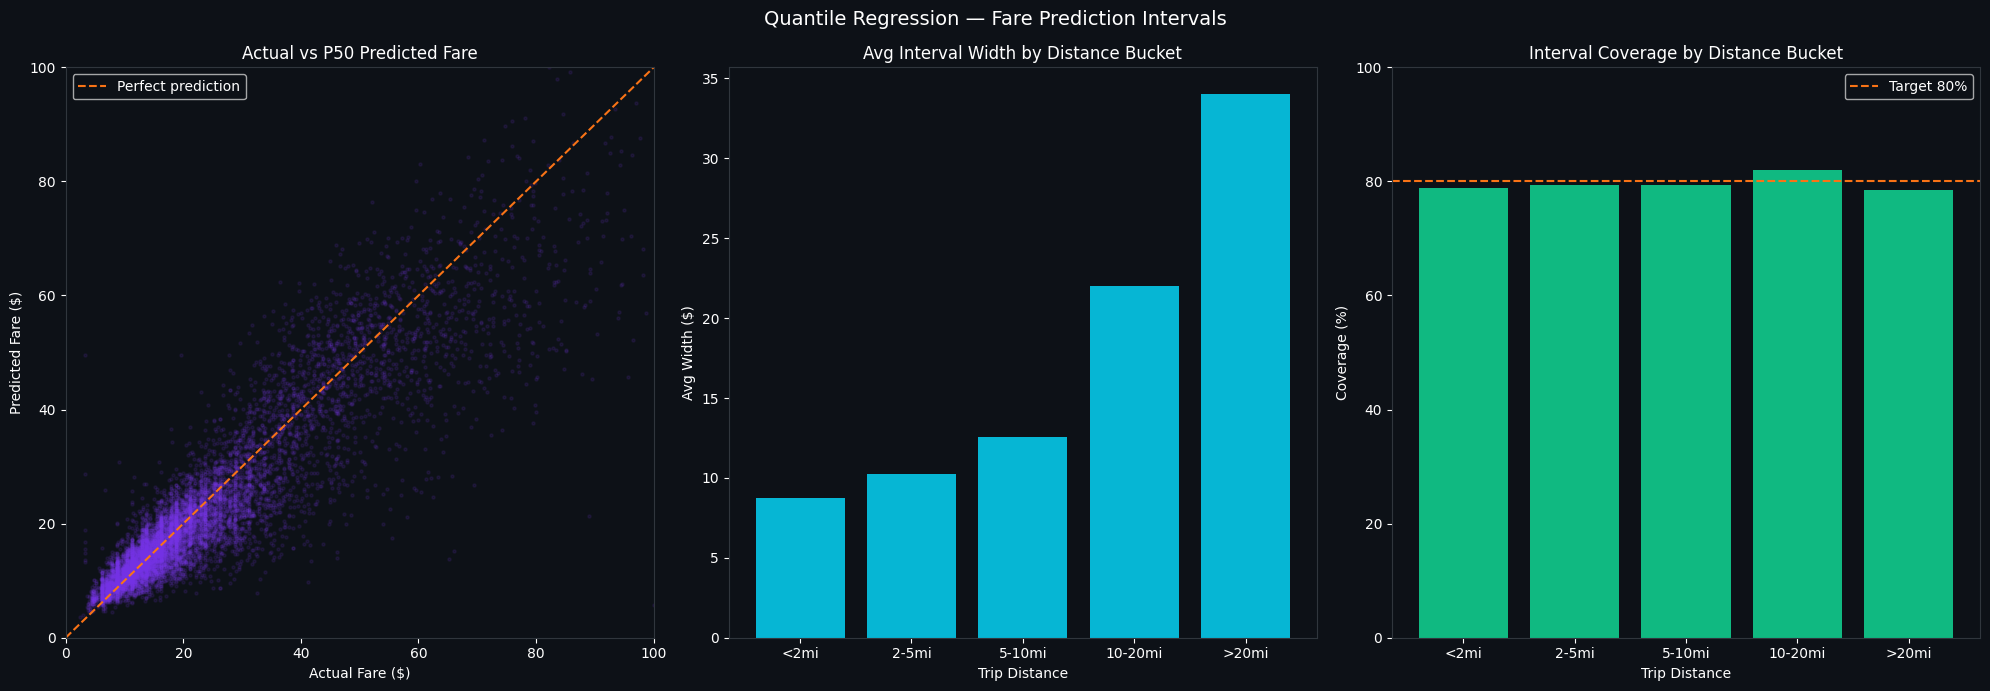

In [16]:
# quantile prediction interval visualization

# sample 10K for plotting
sample_idx = np.random.choice(len(y_raw_test), 10000, replace=False)
actual_sample = y_raw_test.values[sample_idx]
p10_sample    = p10[sample_idx]
p50_sample    = p50[sample_idx]
p90_sample    = p90[sample_idx]
bucket_sample = X_test['trip_distance_bucket'].values[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# plot 1 — actual vs p50 scatter
axes[0].scatter(actual_sample, p50_sample, 
                alpha=0.1, s=5, color='#7c3aed')
axes[0].plot([0, 100], [0, 100], '--', 
             color='#f97316', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].set_title("Actual vs P50 Predicted Fare")
axes[0].set_xlabel("Actual Fare ($)")
axes[0].set_ylabel("Predicted Fare ($)")
axes[0].legend(facecolor='#0d1117', labelcolor='white')

# plot 2 — interval width by distance bucket
bucket_labels = ['<2mi', '2-5mi', '5-10mi', '10-20mi', '>20mi']
widths_by_bucket = []
coverage_by_bucket = []

for b in range(1, 6):
    mask = bucket_sample == b
    if mask.sum() > 0:
        width    = np.mean(p90_sample[mask] - p10_sample[mask])
        coverage = np.mean((actual_sample[mask] >= p10_sample[mask]) &
                          (actual_sample[mask] <= p90_sample[mask]))
        widths_by_bucket.append(width)
        coverage_by_bucket.append(coverage * 100)

axes[1].bar(bucket_labels, widths_by_bucket, 
            color='#06b6d4', edgecolor='none')
axes[1].set_title("Avg Interval Width by Distance Bucket")
axes[1].set_xlabel("Trip Distance")
axes[1].set_ylabel("Avg Width ($)")

# plot 3 — coverage by distance bucket
axes[2].bar(bucket_labels, coverage_by_bucket,
            color='#10b981', edgecolor='none')
axes[2].axhline(80, color='#f97316', linestyle='--',
                linewidth=1.5, label='Target 80%')
axes[2].set_title("Interval Coverage by Distance Bucket")
axes[2].set_xlabel("Trip Distance")
axes[2].set_ylabel("Coverage (%)")
axes[2].set_ylim(0, 100)
axes[2].legend(facecolor='#0d1117', labelcolor='white')

plt.suptitle("Quantile Regression — Fare Prediction Intervals",
             color='white', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\14_quantile_intervals.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 9. Residual Spatial Analysis
Examine whether prediction errors are spatially correlated —
do certain zones have systematically higher or lower residuals?

Spatial autocorrelation in residuals indicates that zone-level
pricing patterns not captured by our features exist.
This informs future work recommendations in the paper.

Analysis:
- Mean residual per pickup zone
- Identify zones with systematic over/under prediction
- Visualize spatial error distribution

Residual Spatial Analysis
Overall mean residual : $0.7224
Overall MAE           : $4.41

Top 5 zones with systematic OVER-prediction (negative residual):
 zone  mean_residual  abs_residual  avg_actual_fare
   11       0.231619      2.861114        17.839457
   58       0.331236      2.741862        16.951484
   18       0.350491      2.680394        17.664782
   19       0.353952      2.606817        16.983559
    2       0.355759      2.661865        17.059127

Top 5 zones with systematic UNDER-prediction (positive residual):
 zone  mean_residual  abs_residual  avg_actual_fare
   72       0.826808      4.078981        21.861637
   32       0.896917      5.023356        24.045659
   33       1.077745      5.788142        25.517328
   76       1.319221      9.004590        50.012356
   56       1.527555      8.694973        41.995607


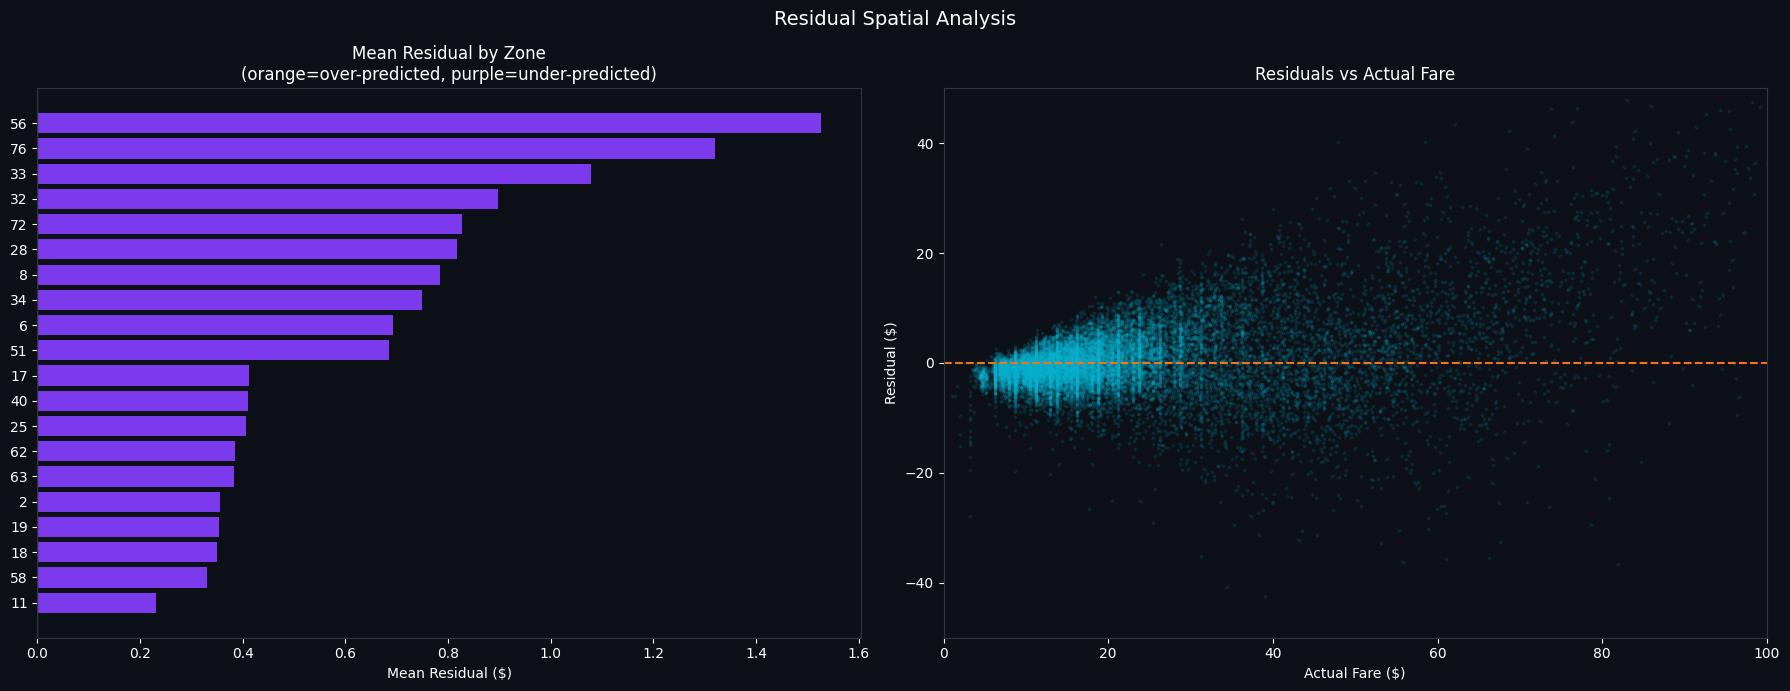

In [17]:
# residual spatial analysis

# compute residuals — actual minus predicted in dollar terms
residuals = y_raw_test.values - np.expm1(xgb_model.predict(X_test))

# residuals by pickup zone
residual_df = pd.DataFrame({
    'zone'    : X_test['pickup_community_area'].values,
    'residual': residuals,
    'actual'  : y_raw_test.values
})

zone_residuals = (
    residual_df[residual_df['zone'] != 0]
    .groupby('zone')
    .agg(
        mean_residual  = ('residual', 'mean'),
        abs_residual   = ('residual', lambda x: np.abs(x).mean()),
        trip_count     = ('residual', 'count'),
        avg_actual_fare= ('actual', 'mean')
    )
    .reset_index()
    .sort_values('mean_residual')
)

print("Residual Spatial Analysis")
print(f"Overall mean residual : ${residuals.mean():.4f}")
print(f"Overall MAE           : ${np.abs(residuals).mean():.2f}")

print(f"\nTop 5 zones with systematic OVER-prediction (negative residual):")
print(zone_residuals.head(5)[['zone', 'mean_residual', 
                               'abs_residual', 'avg_actual_fare']].to_string(index=False))

print(f"\nTop 5 zones with systematic UNDER-prediction (positive residual):")
print(zone_residuals.tail(5)[['zone', 'mean_residual',
                               'abs_residual', 'avg_actual_fare']].to_string(index=False))

# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# mean residual by zone — top and bottom 20
top_bottom = pd.concat([
    zone_residuals.head(10),
    zone_residuals.tail(10)
]).sort_values('mean_residual')

colors = ['#f97316' if r < 0 else '#7c3aed' 
          for r in top_bottom['mean_residual']]

axes[0].barh(top_bottom['zone'].astype(str),
             top_bottom['mean_residual'],
             color=colors, edgecolor='none')
axes[0].axvline(0, color='#30363d', linewidth=1)
axes[0].set_title("Mean Residual by Zone\n(orange=over-predicted, purple=under-predicted)")
axes[0].set_xlabel("Mean Residual ($)")

# residual vs actual fare scatter
sample_mask = np.random.choice(len(residuals), 20000, replace=False)
axes[1].scatter(
    y_raw_test.values[sample_mask],
    residuals[sample_mask],
    alpha=0.1, s=3, color='#06b6d4'
)
axes[1].axhline(0, color='#f97316', linestyle='--', linewidth=1.5)
axes[1].set_title("Residuals vs Actual Fare")
axes[1].set_xlabel("Actual Fare ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(-50, 50)

plt.suptitle("Residual Spatial Analysis", color='white', fontsize=14)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\15_residual_analysis.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 10. SHAP Explainability — Fare Regression
SHAP analysis for the XGBoost fare regression model.
Reveals which features drive high and low fare predictions.

Expected findings based on feature importance:
- trip_miles and log_trip_miles dominant
- is_airport strong positive contributor
- zone_avg_fare validates spatial pricing
- shared_trip_authorized negative contributor (shared = cheaper)

Computed on 5,000 sample — consistent with classification methodology.

Computing SHAP values for regression...
SHAP values shape: (5000, 47)


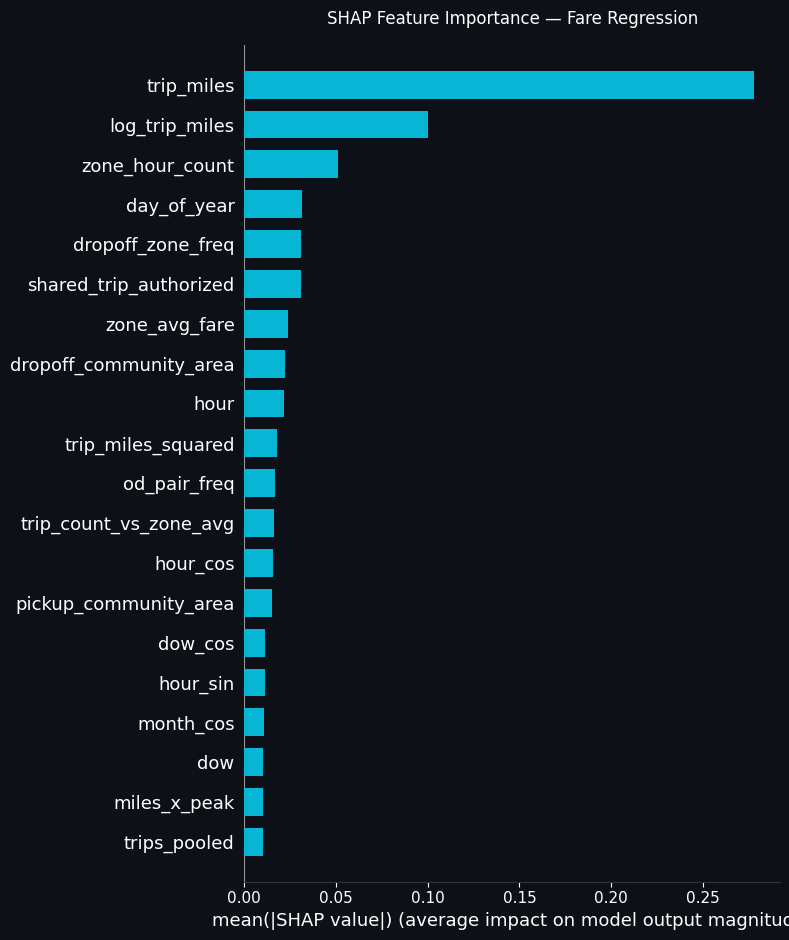

SHAP regression plot saved.


In [18]:
# shap explainability — fare regression

print("Computing SHAP values for regression...")
shap_sample_idx = X_test.sample(5000, random_state=42).index
X_shap_reg = X_test.loc[shap_sample_idx]

explainer_reg   = shap.TreeExplainer(xgb_model)
shap_values_reg = explainer_reg.shap_values(X_shap_reg)

print(f"SHAP values shape: {shap_values_reg.shape}")

# global importance plot
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

shap.summary_plot(
    shap_values_reg, X_shap_reg,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    max_display=20,
    show=False,
    color='#06b6d4'
)

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
plt.title("SHAP Feature Importance — Fare Regression",
          color='white', pad=15)
plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\16_shap_regression.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("SHAP regression plot saved.")

## 11. Regression Model Comparison Summary
Consolidate all regression results — Table 2 for the paper.

Key finding: ETA proxy features (trip duration) add zero improvement
over pre-booking features alone (ΔR²=-0.0002) — demonstrating that
route distance and demand features fully capture fare-relevant
pre-booking information.

Regression Results — Table 2
                           Model     R²  RMSE ($)  MAE ($)                                               Notes
     Ridge Regression (baseline) 0.7589      9.11     5.43                       Linear baseline — 500K sample
   XGBoost Model A (pre-booking) 0.8327      7.66     4.41       Primary model — 47 features, pre-booking only
XGBoost Model B (with ETA proxy) 0.8325      7.66     4.42   Sensitivity — adds duration proxy, no improvement
           LightGBM P50 Quantile 0.8234      7.91     4.48 Prediction intervals — P10/P50/P90, 79.31% coverage


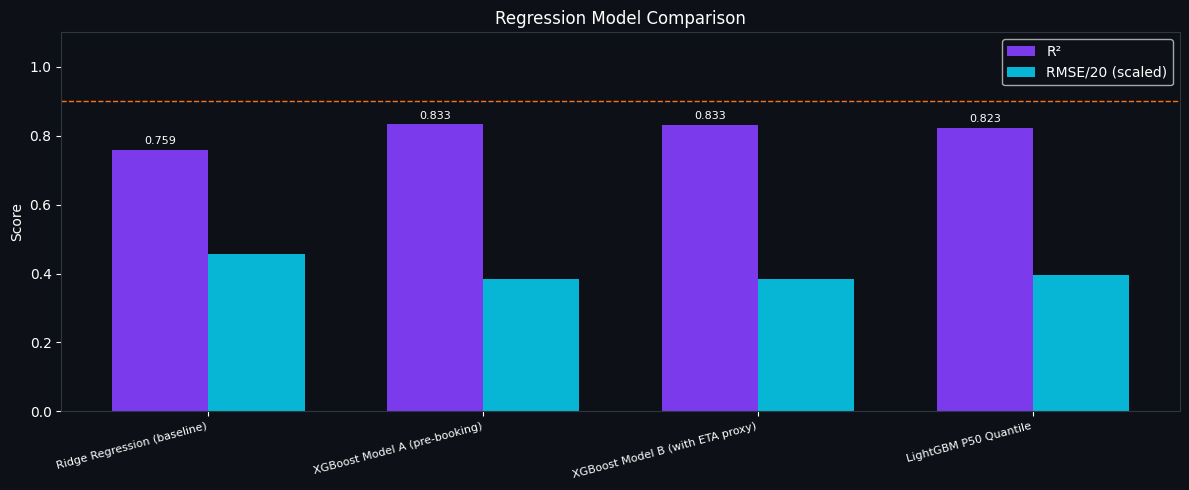


Key finding:
  ETA proxy improvement: -0.0002 R² — duration adds zero value
  Quantile coverage    : 79.31% — near perfect 80% target
  Interval width       : $13.79 avg — actionable fare range


: 

In [ ]:
# regression model comparison — Table 2 for the paper

results_reg = {
    'Model': [
        'Ridge Regression (baseline)',
        'XGBoost Model A (pre-booking)',
        'XGBoost Model B (with ETA proxy)',
        'LightGBM P50 Quantile'
    ],
    'R²': [0.7589, 0.8327, 0.8325, 0.8234],
    'RMSE ($)': [9.11, 7.66, 7.66, 7.91],
    'MAE ($)': [5.43, 4.41, 4.42, 4.48],
    'Notes': [
        'Linear baseline — 500K sample',
        'Primary model — 47 features, pre-booking only',
        'Sensitivity — adds duration proxy, no improvement',
        'Prediction intervals — P10/P50/P90, 79.31% coverage'
    ]
}

results_reg_df = pd.DataFrame(results_reg)
print("Regression Results — Table 2")
print(results_reg_df.to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

models   = results_reg['Model']
r2_scores = results_reg['R²']
rmse_scores = results_reg['RMSE ($)']

x     = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, r2_scores, width,
               label='R²', color='#7c3aed', edgecolor='none')
bars2 = ax.bar(x + width/2, [r/20 for r in rmse_scores], width,
               label='RMSE/20 (scaled)', color='#06b6d4', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Regression Model Comparison", color='white')
ax.legend(facecolor='#0d1117', labelcolor='white')
ax.axhline(0.90, color='#f97316', linestyle='--',
           linewidth=1, label='R² target (0.90)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            color='white', fontsize=8)

plt.tight_layout()
plt.savefig(r"E:\Projects\ML\Transport taxi chicago\data\plots\17_regression_comparison.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\nKey finding:")
print(f"  ETA proxy improvement: {0.8325 - 0.8327:.4f} R² — duration adds zero value")
print(f"  Quantile coverage    : 79.31% — near perfect 80% target")
print(f"  Interval width       : $13.79 avg — actionable fare range")